In [34]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Ensure project root is importable regardless of current working directory.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "Revenue").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Revenue.Tarnet.tarnet import Tarnet
from Revenue.CFRnet.cfrnet import CFRnet as Cfrnet
from Revenue.Dragonnet.dragonnet import Dragonnet
from xgboost import XGBClassifier # SỬ DỤNG XGBClassifier CHO CONVERSION
from lightgbm import LGBMRegressor # SỬ DỤNG LGBMClassifier CHO CONVERSION
from sklift.models import SoloModel, TwoModels
from metrics import auqc, auuc
from utils import seed_everything
# Example usage
# tarnet_model = Tarnet(input_dim=..., hidden_dim=...)
# cfrnet_model = Cfrnet(input_dim=..., hidden_dim=...)
# dragonnet_model = Dragonnet(input_dim=..., hidden_dim=...)

In [35]:
%time train_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 28.6 ms, sys: 6.01 ms, total: 34.6 ms
Wall time: 33.7 ms
CPU times: user 14.5 ms, sys: 4 ms, total: 18.5 ms
Wall time: 18.7 ms
CPU times: user 5.21 ms, sys: 0 ns, total: 5.21 ms
Wall time: 5.21 ms


In [36]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [37]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [38]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [39]:
dict_conv_models = {}

In [40]:
epochs = 150
activation = torch.nn.ReLU

Locked random seed: 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Loss: 532.8884 | Val Loss: 498.8486 | Val Qini: 0.1857 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.1857 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Loss: 239.4045 | Val Loss: 498.8139 | Val Qini: 0.2895 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2013 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Loss: 554.9581 | Val Loss: 498.7799 | Val Qini: 0.3568 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2246 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Loss: 535.7191 | Val Loss: 498.7455 | Val Qini: 0.4313 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2556 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Loss: 352.6376 | Val Loss: 498.7108 | Val Qini: 0.4658 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2872 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/150 | Lo

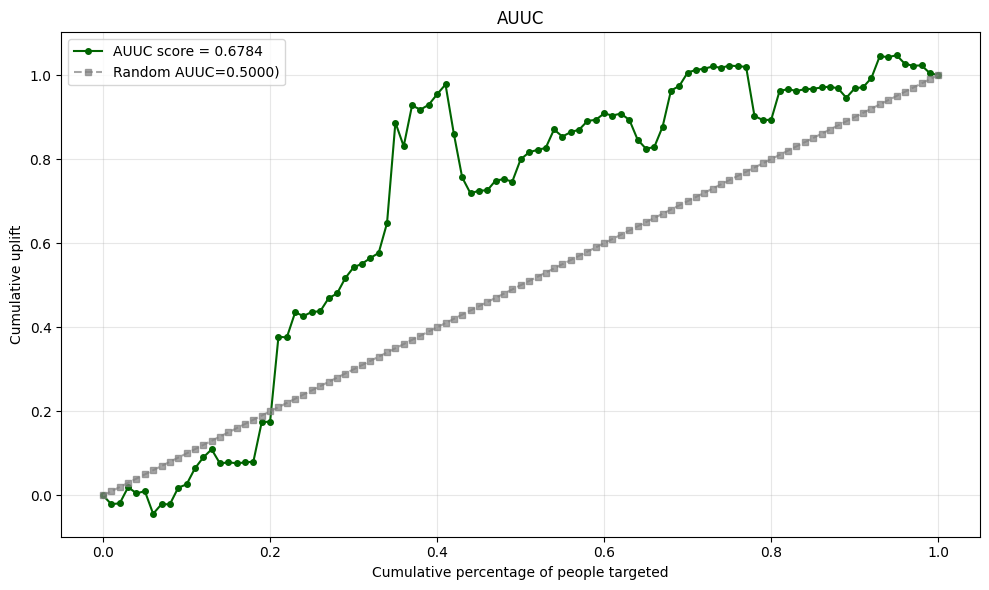

TARNet AUUC: 0.678351


In [41]:
seed_everything(902745)
tarnet = Tarnet(
        input_dim=x_men_train_t.shape[1], epochs=epochs, learning_rate=5.10E-05, 
        weight_decay=1e-5, use_ema=True, ema_alpha=0.15, patience=20,
        shared_hidden=200, outcome_hidden=100,
        outcome_dropout=0, shared_dropout=0,
        early_stop_metric="qini", early_stop_start_epoch=30,
        activation=activation
    )
tarnet.fit(train_loader, val_loader)
y0_pred, y1_pred = tarnet.predict(x_men_test_t)
uplift_pred_tarnet = (y1_pred - y0_pred).detach().cpu().numpy().flatten()

auuc_tarnet = auuc(y_true=y_test.flatten(), t_true=t_test.flatten(), uplift_pred=uplift_pred_tarnet, bins=100)
print(f"TARNet AUUC: {auuc_tarnet:.6f}")

In [42]:
seed_everything(1)
dragonnet = Dragonnet(
    input_dim=x_men_train_t.shape[1], epochs=epochs, learning_rate=5e-5, 
    alpha=1, beta=1,
    weight_decay=1e-5, ema_alpha=0.35, patience=20,
    shared_hidden=200, outcome_hidden=100,
    outcome_droupout=0, shared_dropout=0,
    early_stop_metric="qini", early_stop_start_epoch=30,
    use_ema= True,
    activation=activation
    )
dragonnet.fit(train_loader, val_loader)
y0_pred, y1_pred,_,_ = dragonnet.predict(x_men_test_t)
uplift_pred_dragonnet = (y1_pred - y0_pred).detach().cpu().numpy().flatten()


Locked random seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.35)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Base Loss: 440.4164 | Tarreg Loss: 222.030350 | Total Loss: 662.4468 | Val Loss: 499.8079 | Raw Qini: 0.6106 | EMA Trend: 0.6106 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 336.7243 | Tarreg Loss: 171.007690 | Total Loss: 507.7320 | Val Loss: 499.7771 | Raw Qini: 0.5983 | EMA Trend: 0.6063 | (patience: 1/20)
Epoch 3/150 | Base Loss: 713.8735 | Tarreg Loss: 356.583923 | Total Loss: 1070.4574 | Val Loss: 499.7472 | Raw Qini: 0.5862 | EMA Trend: 0.5992 | (patience: 2/20)
Epoch 4/150 | Base Loss: 553.6613 | Tarreg Loss: 278.935760 | Total Loss: 832.5970 | Val Loss: 499.7177 | Raw Qini: 0.5803 | EMA Trend: 0.5926 | (patience: 3/20)
Epoch 5/150 | Base Loss: 437.9907 | Tarreg Loss: 219.378311 

Epoch 15/150 | Base Loss: 479.1862 | Tarreg Loss: 240.964813 | Total Loss: 720.1511 | Val Loss: 499.2533 | Raw Qini: 0.5886 | EMA Trend: 0.5739 | ✓ above trend but not peak (patience: 14/20)
Epoch 16/150 | Base Loss: 598.7819 | Tarreg Loss: 302.676605 | Total Loss: 901.4585 | Val Loss: 499.1835 | Raw Qini: 0.6095 | EMA Trend: 0.5864 | ✓ above trend but not peak (patience: 15/20)
Epoch 17/150 | Base Loss: 539.0743 | Tarreg Loss: 268.757538 | Total Loss: 807.8318 | Val Loss: 499.1056 | Raw Qini: 0.6280 | EMA Trend: 0.6009 | ⭐ NEW BEST (peak ≥ trend)
Epoch 18/150 | Base Loss: 475.8146 | Tarreg Loss: 239.102142 | Total Loss: 714.9167 | Val Loss: 499.0177 | Raw Qini: 0.6439 | EMA Trend: 0.6160 | ⭐ NEW BEST (peak ≥ trend)
Epoch 19/150 | Base Loss: 414.8018 | Tarreg Loss: 208.394119 | Total Loss: 623.1960 | Val Loss: 498.9190 | Raw Qini: 0.6580 | EMA Trend: 0.6307 | ⭐ NEW BEST (peak ≥ trend)
Epoch 20/150 | Base Loss: 680.9482 | Tarreg Loss: 340.199463 | Total Loss: 1021.1477 | Val Loss: 498.8

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:328: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return y0_pred, y1_pred, t_pred, eps


In [43]:
seed_everything(42)
cfr = Cfrnet(
    input_dim=x_men_train_t.shape[1],
    epochs=epochs,
    alpha=1.0,
    learning_rate=1e-4,
    weight_decay=1e-5,
    method="mmd_linear",
    ema_alpha=0.35, patience=20,
    shared_hidden=200, outcome_hidden=100,
    outcome_dropout=0, shared_dropout=0,
    early_stop_metric="qini", early_stop_start_epoch=30,
    use_ema= True,
    activation=activation
    )
cfr.fit(train_loader, val_loader)
y0_pred, y1_pred = cfr.predict(x_men_test_t)
uplift_pred_cfr = (y1_pred - y0_pred).detach().cpu().numpy().flatten()


Locked random seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.35)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Loss: 340.1026 | Val Loss: 498.6601 | Val Qini: 0.2080 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2080 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Loss: 606.3744 | Val Loss: 498.6100 | Val Qini: 0.2026 (patience: 1/20)EMA Trend: 0.2061 | (patience: 1/20)
Epoch 3/150 | Loss: 420.8389 | Val Loss: 498.5584 | Val Qini: 0.2342 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2159 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Loss: 478.4040 | Val Loss: 498.5021 | Val Qini: 0.3113 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2493 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Loss: 478.7498 | Val Loss: 498.4408 | Val Qini: 0.3681 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2909 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/150 | Loss: 174.4085 | Val 

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/CFRnet/cfrnet.py:276: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  


Locked random seed: 42
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 300
[LightGBM] [Info] Number of data points in the train set: 25567, number of used features: 11
[LightGBM] [Info] Start training from score 1.059573
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/ducvu0904/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ducvu0904/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/ducvu0904/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


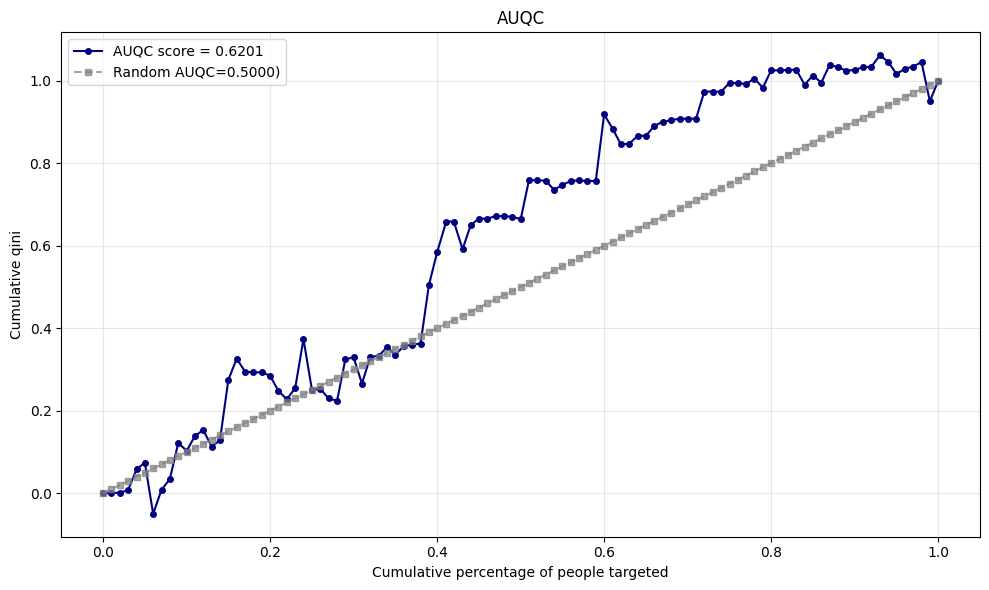

S-Learner (LGBM) AUQC: 0.620102


In [44]:
seed_everything(42)
base_model = LGBMRegressor(
    n_estimators=51,            
    learning_rate=2.65E-02,
    max_depth=9,
    num_leaves=127,
    min_child_samples=46,
    subsample=0.9656012519,
    colsample_bytree=0.9626626187,
    random_state=42,
    n_jobs=-1
)
s_learner = SoloModel(estimator=base_model)
        
s_learner.fit(X=X_train, y=y_train, treatment=t_train)
uplift_pred_s_learner = s_learner.predict(X_test)

auqc_s_learner = auqc(y_true=y_test.flatten(), t_true=t_test.flatten(), uplift_pred=uplift_pred_s_learner.flatten(), bins=100)
print(f"S-Learner (LGBM) AUQC: {auqc_s_learner:.6f}")

In [45]:
# seed_everything(42)

# model_trmnt = LGBMClassifier(**params, random_state=42, verbose=-1)
# model_ctrl = LGBMClassifier(**params, random_state=42, verbose=-1)

# # Bọc vào TwoModels (T-Learner)
# t_learner = TwoModels(estimator_trmnt=model_trmnt, estimator_ctrl=model_ctrl, method='vanilla')

# # Huấn luyện mô hình
# t_learner.fit(X=X_train, y=y_train, treatment=t_train)

In [46]:
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

/tmp/ipykernel_51164/2873044765.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', num_models)


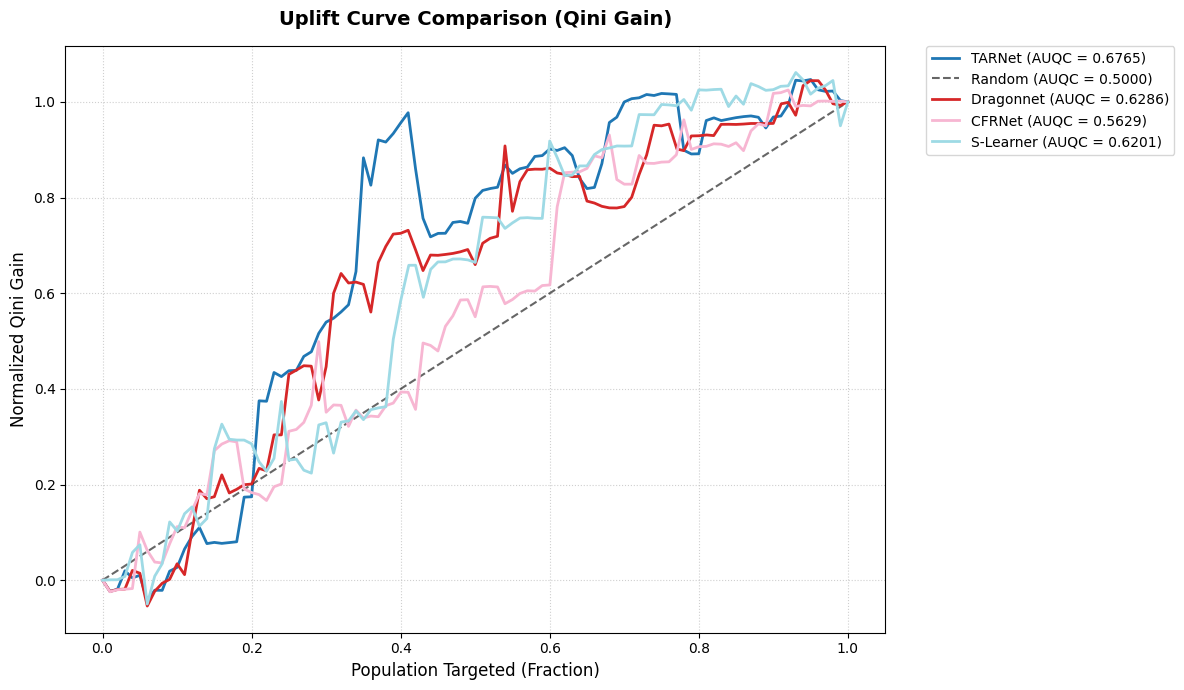

In [47]:
def auqc_core(y_true, t_true, uplift_pred, bins=100):
    """
    Hàm này CHÍNH LÀ hàm gốc của bạn, không đổi một dấu phẩy ở logic toán,
    chỉ bỏ phần plot đi để trả về dữ liệu vẽ.
    """
    y_true = np.array(y_true).flatten()
    t_true = np.array(t_true).flatten()
    uplift_pred = np.array(uplift_pred).flatten()

    data = pd.DataFrame({'y': y_true, "t": t_true, "pred": uplift_pred})
    # Thêm kind='mergesort' để đảm bảo sort luôn nhất quán
    data = data.sort_values(by="pred", ascending=False, kind='mergesort').reset_index(drop=True)
    
    try:
        data["bucket"] = pd.qcut(-data['pred'], bins, labels=False, duplicates="drop")
    except:
        data['bucket'] = pd.cut(-data['pred'], bins, labels=False)
    
    cumulative_gain = []
    population = []
    bucket_ids = sorted(data['bucket'].unique())
    
    for bucket_id in bucket_ids:
        cumulative_data = data.loc[data['bucket'] <= bucket_id]
        
        control_group = cumulative_data.loc[cumulative_data['t']==0]
        treatment_group =  cumulative_data.loc[cumulative_data['t']==1]
        
        n_control = len(control_group)
        n_treatment = len(treatment_group)
        n_total = n_control + n_treatment
        
        if n_control==0 or n_total==0:
            continue
        
        sum_y_control = control_group['y'].sum()
        sum_y_treatment = treatment_group['y'].sum()
        qini_gain = sum_y_treatment - sum_y_control * (n_treatment/n_control)
        
        cumulative_gain.append(qini_gain)
        population.append(n_total)
        
    if len(cumulative_gain) == 0:
        return np.array([0]), np.array([0]), 0.0, np.array([0])
    
    gap0 = cumulative_gain[-1]
    norm_factor = abs(gap0) if abs(gap0) > 1e-9 else 1.0
    cumulative_gains_norm = [x / norm_factor for x in cumulative_gain]
    
    pop_max = max(population)
    pop_fraction = [p/pop_max for p in population]
    
    x_curve = np.append(0, pop_fraction)
    y_curve = np.append(0, cumulative_gains_norm)
    y_rand = x_curve * y_curve[-1]
    
    qini_score = np.trapezoid(y_curve, x_curve)
    
    # Trả về các tham số để plot
    return x_curve, y_curve, qini_score, y_rand

# ==========================================
# HÀM VẼ (DÙNG CORE CỦA BẠN)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Thêm thư viện này để lấy bảng màu

def plot_compare_auqc(dict_preds, y_true, t_true, bins=100):
    plt.figure(figsize=(12, 7), facecolor='#ffffff')
    
    # 1. Tự động tạo bảng màu dựa trên số lượng model trong dict
    num_models = len(dict_preds)
    # Sử dụng 'tab10' nếu < 10 model, 'tab20' nếu nhiều hơn
    colormap = cm.get_cmap('tab20', num_models) 
    
    random_plotted = False
    
    # Sắp xếp dict theo tên model (tùy chọn) để thứ tự màu sắc ổn định
    for i, (name, preds) in enumerate(dict_preds.items()):
        # GỌI HÀM CORE CỦA BẠN
        x_c, y_c, score, y_r = auqc_core(y_true, t_true, preds, bins)
        
        # Vẽ đường của model với màu từ colormap
        plt.plot(x_c, y_c, lw=2, label=f"{name} (AUQC = {score:.4f})", color=colormap(i))
        
        # Vẽ đường Random duy nhất một lần
        if not random_plotted:
            rand_score = np.trapezoid(y_r, x_c)
            plt.plot(x_c, y_r, color='black', linestyle='--', lw=1.5, alpha=0.6, label=f'Random (AUQC = {rand_score:.4f})')
            random_plotted = True

    plt.title("Uplift Curve Comparison (Qini Gain)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Population Targeted (Fraction)", fontsize=12)
    plt.ylabel("Normalized Qini Gain", fontsize=12)
    
    # 2. Đẩy chú thích ra ngoài phía bên phải để không che đồ thị
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout() # Tự động căn chỉnh để không mất phần legend bên phải
    plt.show()

# --- CÁCH SỬ DỤNG KHI CÓ NHIỀU MODEL ---
# Bạn chỉ cần thêm vào dictionary, không giới hạn số lượng
dict_conv_models = {
    'TARNet': uplift_pred_tarnet,
    'Dragonnet': uplift_pred_dragonnet,
    'CFRNet': uplift_pred_cfr,
    'S-Learner': uplift_pred_s_learner,
    # 'T-Learner': uplift_pred_t_learner,
    # 'X-Learner': uplift_pred_x_learner,
    # 'R-Learner': uplift_pred_r_learner,
    # Thêm bao nhiêu tùy ý...
}

plot_compare_auqc(dict_conv_models, y_true, t_true, bins=100)